**A DATA-DRIVEN COMPARISON OF MACHINE LEARNING MODELS FOR PREDICTING EMPLOYEE ATTRITION INTENTION**

04 — SHAP Interpretability Analysis

This notebook covers SHAP (SHapley Additive Explanations) analysis applied to the CatBoost model — the best performing model with 77.63% accuracy. SHAP TreeExplainer identifies the top 10 most influential features affecting employee attrition intention with beeswarm plot and bar chart visualisations.

**6. SHAP Analysis**

SHAP (SHapley Additive Explanations) is applied to the CatBoost model to explain which features most strongly influence employee attrition intention.

6.1 SHAP Beeswarm Summary Plot

Shape: (76, 23)


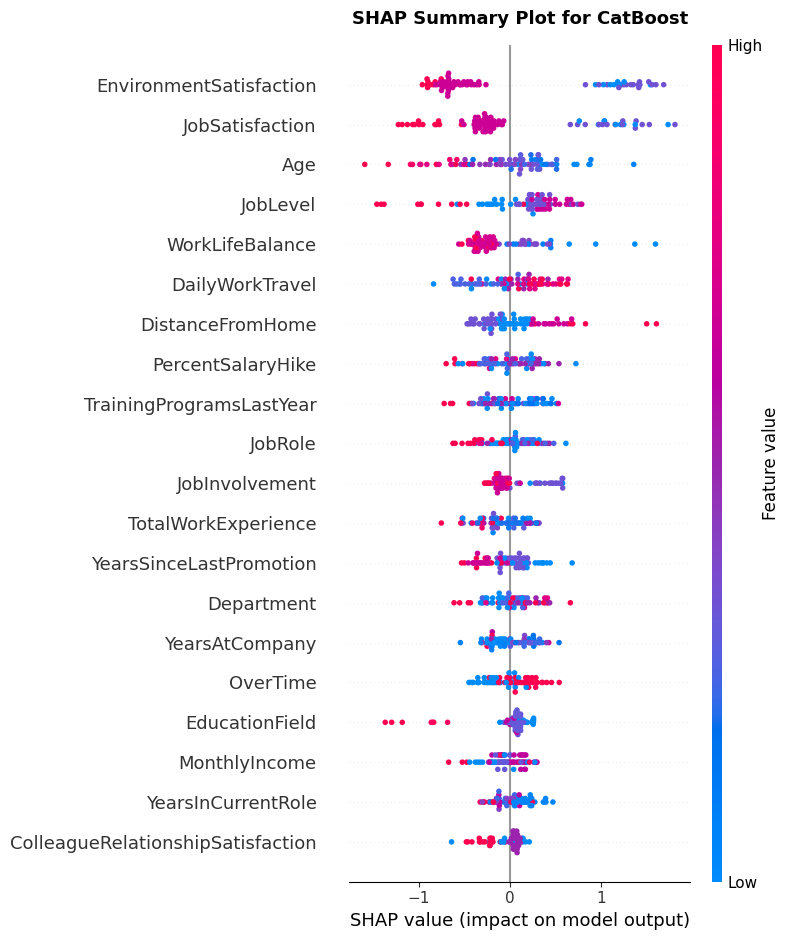

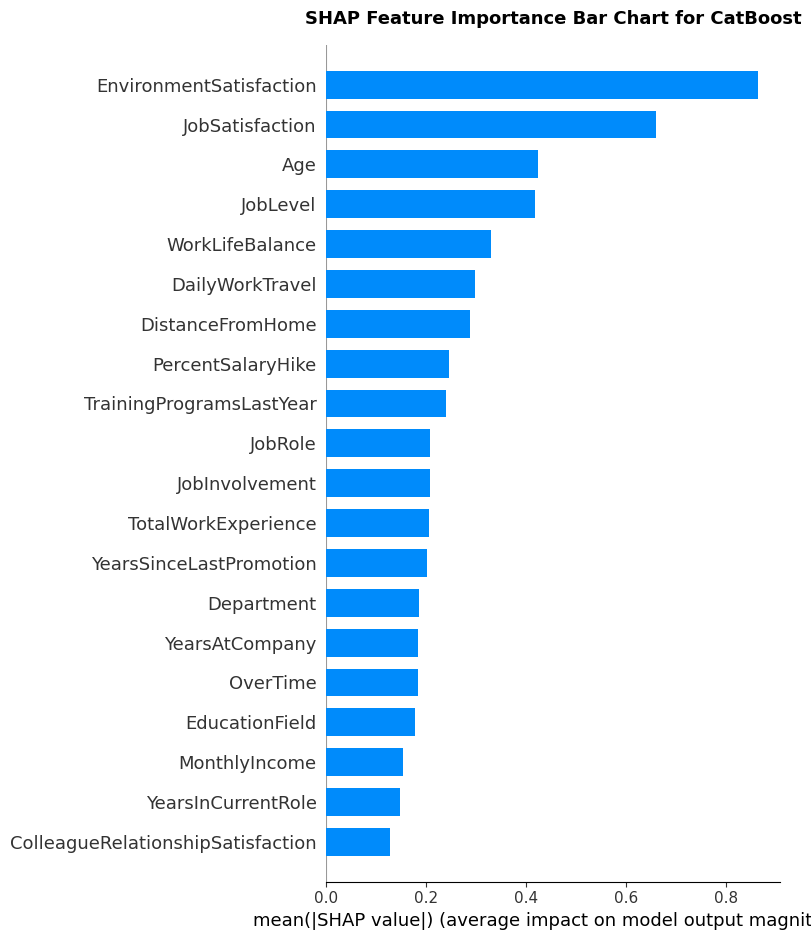


Top 10 Features by SHAP Importance (CatBoost):
                 Feature  SHAP_Importance
 EnvironmentSatisfaction         0.863795
         JobSatisfaction         0.658785
                     Age         0.424089
                JobLevel         0.416512
         WorkLifeBalance         0.328243
         DailyWorkTravel         0.297787
        DistanceFromHome         0.287645
       PercentSalaryHike         0.245033
TrainingProgramsLastYear         0.238596
                 JobRole         0.207516


In [ ]:
# =========================================================
# SHAP ANALYSIS ON CATBOOST (Best Performing Model)
# =========================================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier

# Train CatBoost for SHAP
cb_shap = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.1,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cb_shap.fit(X_train, y_train)

# SHAP TreeExplainer on CatBoost
explainer = shap.TreeExplainer(cb_shap)
shap_values = explainer.shap_values(X_test)

# CatBoost returns 2D array directly for binary classification
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    shap_class1 = shap_values
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_class1 = shap_values[:, :, 1]
else:
    shap_class1 = shap_values

print("Shape:", shap_class1.shape)

# ── Beeswarm Plot ─────────────────────────────────────
shap.summary_plot(
    shap_class1,
    X_test,
    feature_names=list(X_test.columns),
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot for CatBoost",
          fontsize=13, fontweight="bold", loc="center", pad=15)
plt.tight_layout()
plt.show()

# ── Bar Chart ─────────────────────────────────────────
shap.summary_plot(
    shap_class1,
    X_test,
    feature_names=list(X_test.columns),
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance Bar Chart for CatBoost",
          fontsize=13, fontweight="bold", loc="center", pad=15)
plt.tight_layout()
plt.show()

# ── Top 10 Features Table ─────────────────────────────
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Importance": np.abs(shap_class1).mean(axis=0)
}).sort_values("SHAP_Importance", ascending=False).reset_index(drop=True)

print("\nTop 10 Features by SHAP Importance (CatBoost):")
print(shap_importance.head(10).to_string(index=False))